In [1]:
import pandas as pd
import numpy as np
import re, os
from pathlib import Path

In [6]:
DATASET = Path('../data/dataset') 
files = {
    'bathroom':    'bathroom_dataset.csv',
    'bedroom':     'bedroom_dataset.csv',
    'home-office': 'home_office_dataset.csv',
    'kitchen':     'kitchen_dataset.csv',
    'living-room': 'living_room_dataset.csv',
    'pool':        'pool-ideas_dataset.csv',
}
# loop over every room→file pair, read the CSV, store as DataFrame
# DATASET / fname builds the path: e.g. dataset/bathroom_dataset.csv
# result: dfs['bathroom'] = DataFrame, dfs['kitchen'] = DataFrame, ...
dfs = {}
for room, fname in files.items():
    dfs[room] = pd.read_csv(DATASET / fname)

# fix pool labeling bug   →  pool file has room_type='dining-room' by mistake , 
# we trust the filename instead

In [7]:
# BUG: the pool CSV had room_type='dining-room' on every row by mistake
# FIX: overwrite the room_type column using the dictionary key (the correct name)
# we do this for ALL 6 rooms to guarantee zero label inconsistencies
for room, d in dfs.items():  # room = room name | d = its DataFrame
    d['room_type'] = room    # stamp the correct label


# combine all 6 files into one DataFrame   →  keep only what captioning needs

In [ ]:
# stack all 6 DataFrames vertically into one big table
# ignore_index=True → reset index to 0,1,2,... instead of keeping each file's index
df = pd.concat(dfs.values(), ignore_index=True)

# keep only the 3 columns we actually need for captioning
# local_path = image path on disk | description = caption text | room_type = room label
df = df[['local_path', 'description', 'room_type']].copy()  # .copy() avoids pandas warnings
print(len(df)) # -> row 24042
print(df.shape[1]) # -> col 3

df.head(3) # -> just  see the frist 3  

24042
3


,local_path,description,room_type
0,images/bathroom/bathroom_00000.jpg,Bathroom - country white tile white floor bath...,bathroom
1,images/bathroom/bathroom_00001.jpg,We transformed a mid-terrace Victorian bathroo...,bathroom
2,images/bathroom/bathroom_00002.jpg,Inspiration for a transitional multicolored ti...,bathroom


# text cleaning   →  url removal , whitespace normalization , photographer credits

In [10]:
URL_RE      = re.compile(r'https?://\S+|www\.\S+') 
PIPE_PREFIX = re.compile(r'^[^|\n]{1,80}\|[^|\n]{1,80}\|[^|\n]{1,80}\s*') 
WHITESPACE  = re.compile(r'\s+')
"""

URL_RE — matches any web URL starting with http://, https://, or www. and removes it

PIPE_PREFIX — some Houzz captions started with a "Project | Location | Firm" prefix
separated by pipe characters. This regex detects and strips that pattern.

WHITESPACE — collapses multiple spaces/newlines into a single space


"""

def basic_clean(s):
    s = str(s) # make sure input is a string
    s = PIPE_PREFIX.sub('', s)# remove "Title | Location | Firm" prefix
    s = URL_RE.sub('', s)# remove any URLs
    s = WHITESPACE.sub(' ', s).strip()# collapse multiple spaces into one, trim edges
    return s


df['description'] = df['description'].apply(basic_clean) #  run it  for every caption 
len(df)

24042

# drop UI scraping garbage   →  rows starting with "All Filters" are sidebar text

During scraping, Selenium sometimes accidentally captured Houzz's sidebar filter UI text instead of the actual caption. These rows start with the literal text "All Filters Style Contemporary Modern Traditional..." — clearly not a photo description.

~df['description'].str.startswith('All Filters') — the ~ is a boolean NOT, so this keeps only rows that do NOT start with that prefix. reset_index(drop=True) re-numbers the index from 0 after dropping rows. 

In [ ]:
# ~ means NOT → keep only rows that do NOT start with that prefix

before = len(df)
df = df[~df['description'].str.startswith('All Filters', na=False)].reset_index(drop=True)
print(before - len(df)) # here we # dropped 5021 rows
print(len(df))  # data after  clean ui 

5021
19021


# Define Template-Stripping Patterns

In [13]:
# PROBLEM: Houzz captions follow a template like:
# "Inspiration for a transitional master bedroom design in Denver with white walls."
# Cities, style words, credits → NOT visible in the photo → model would hallucinate them
# SOLUTION: strip all non-visual metadata with 7 regex patterns



# 1. boilerplate intros like "Example of a", "Inspiration for a", "Photo of a"
INTRO_RE = re.compile(
    r'\b(example\s+of\s+a?n?|inspiration\s+for\s+a?n?|idea\s+for\s+a?n?|photo\s+of\s+a?n?)\s*',
    flags=re.IGNORECASE # it's ok upper or lower 
)

# 2. "Bathroom -" or "Kitchen:" at the very start of the caption
ROOM_PREFIX_RE = re.compile(
    r'^\s*(bathroom|bedroom|kitchen|living\s*room|dining\s*room|home\s*office|study\s*room|pool)s?\s*[-:]\s*',
    flags=re.IGNORECASE
)

# 3. city names like "in Denver", "in San Francisco"
#    case-sensitive (flags=0) because cities are capitalized → avoids false matches
CITY_RE = re.compile(
    r'\s+in\s+[A-Z][a-zA-Z\.]+(?:\s+[A-Z][a-zA-Z\.]+){0,3}(?:\s*,\s*[A-Z][a-zA-Z\.]+(?:\s+[A-Z][a-zA-Z\.]+){0,1})?(?=\s+with\b|\s+and\b|\s*[\.,;]|$)',
    flags=0 #-> case-sensitive
)
CITY_OTHER_RE = re.compile(r'\s+in\s+other\b', flags=re.IGNORECASE) # edge case: "in other"

# 4. size words
SIZE_RE = re.compile(
    r'\b(small|mid[\s-]?sized|medium[\s-]?sized|large|huge)\b',
    flags=re.IGNORECASE 
)

# 5. style words
STYLE_WORDS = [
    'transitional', 'traditional', 'contemporary', 'modern',
    'mid[\\s-]?century', 'farmhouse', 'industrial', 'scandinavian',
    'rustic', 'coastal', 'eclectic', 'southwestern', 'tropical',
    'craftsman', 'asian', 'victorian', 'mediterranean',
    'shabby chic', 'arts and crafts', 'mountain style', 'beach style',
    'classic', 'trendy', 'vintage', 'timeless', 'minimalist',
    'tuscan', 'spanish style'
]
STYLE_RE = re.compile(r'\b(?:' + '|'.join(STYLE_WORDS) + r')\b', flags=re.IGNORECASE)

# 6. trailing boilerplate after room name: "bathroom design", "kitchen remodel"
#    keeps the room name but drops the generic word after it
TRAILING_BOILERPLATE = re.compile(
    r'\b(bathroom|bedroom|kitchen|living\s*room|dining\s*room|home\s*office|study\s*room|pool)\s+(design|remodel|idea|photo|inspiration)\b',
    flags=re.IGNORECASE
)

# 7. photographer / designer credits ANYWHERE
PHOTO_CREDITS = re.compile(
    r'(?:'
    r'(?:photo(?:graphy)?|photos?)\s+by\s+[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,4}' # "Photo by John Smith"
    r'|'
    r'\b[A-Z][\w\.\-\']+(?:\s+[A-Z][\w\.\-\']+){0,3}\s+Photography\b' # "John Smith Photography"
    r'|'
    r'\b(?:photography|photographer)\b'  # standalone word
    r'|'
    r'©\s*\d{0,4}\s*[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,4}'  # "© 2018 Studio X"
    r'|'
    r'\bby\s+designer\s+[A-Za-z][\w\.\-\']+(?:\s+[A-Za-z][\w\.\-\']+){0,3}'# "by designer Jane"
    r')',
    flags=re.IGNORECASE
)


def strip_templates(s):
    s = str(s)
    s = PHOTO_CREDITS.sub('', s)                 # remove credits first (may contain city-like names)
    s = ROOM_PREFIX_RE.sub('', s)                # remove "Bathroom -" prefix
    s = INTRO_RE.sub('', s)                      # remove "Inspiration for a" etc.
    s = CITY_RE.sub('', s)                       # remove "in Denver" etc.
    s = CITY_OTHER_RE.sub('', s)                 # remove "in other"
    s = SIZE_RE.sub(' ', s)                      # replace size words with a space
    s = STYLE_RE.sub(' ', s)                     # replace style words with a space
    s = TRAILING_BOILERPLATE.sub(r'\1', s)       # "bathroom design" → "bathroom"

    s = re.sub(r'\s+', ' ', s).strip()           # collapse extra spaces
    s = re.sub(r'^\s*[,;-]\s*', '', s)           # remove leading punctuation leftovers
    s = re.sub(r'\s+([.,;])', r'\1', s)          # fix "word ." → "word."

    return s


# example
ex = "Photography by Anthony Barcelo. Example of a transitional master bedroom design in Denver with white walls."
print('BEFORE:', ex)
print('AFTER :', strip_templates(ex))

BEFORE: Photography by Anthony Barcelo. Example of a transitional master bedroom design in Denver with white walls.
AFTER : a master bedroom with white walls.


# apply to all captions and add word count column

In [15]:
df['description'] = df['description'].apply(strip_templates)
df['wc'] = df['description'].str.split().str.len()

df.describe()

,wc
count,19021.000000
mean,45.757216
std,98.151115
min,0.000000
25%,12.000000
50%,23.000000
75%,39.000000
max,3050.000000


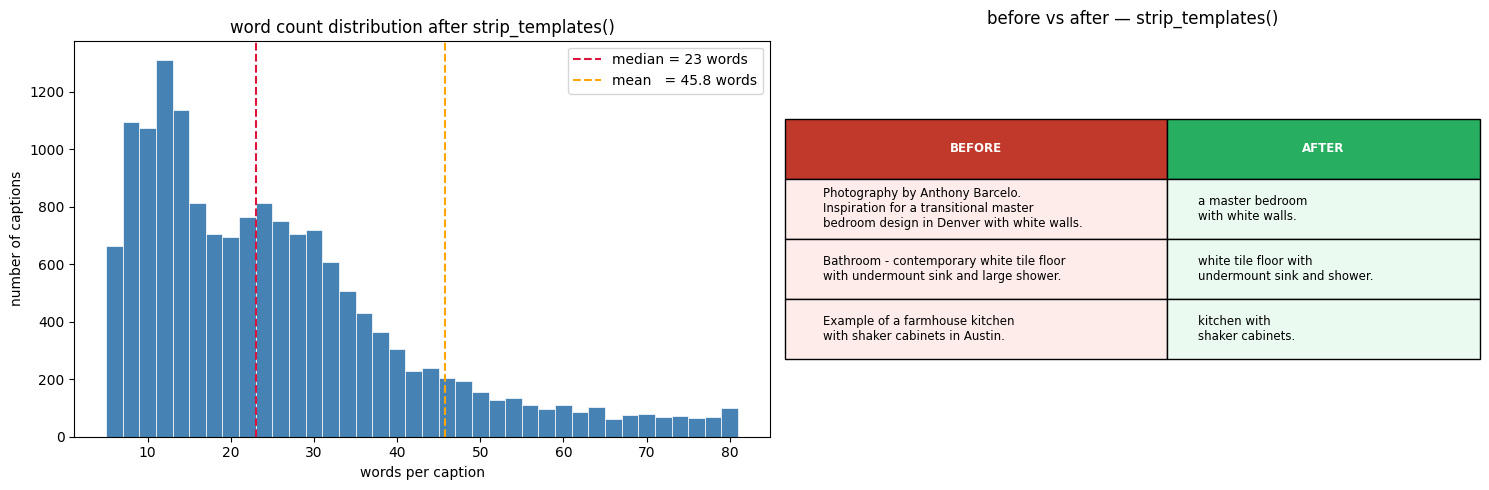

In [ ]:
import matplotlib.pyplot as plt

examples = [
    (
        "Photography by Anthony Barcelo.\nInspiration for a transitional master\nbedroom design in Denver with white walls.",
        "a master bedroom\nwith white walls."
    ),
    (
        "Bathroom - contemporary white tile floor\nwith undermount sink and large shower.",
        "white tile floor with\nundermount sink and shower."
    ),
    (
        "Example of a farmhouse kitchen\nwith shaker cabinets in Austin.",
        "kitchen with\nshaker cabinets."
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── word count histogram ─────────────────────────────────────────────────────
axes[0].hist(df['wc'], bins=range(5, 82, 2), color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['wc'].median(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'median = {df["wc"].median():.0f} words')
axes[0].axvline(df['wc'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'mean   = {df["wc"].mean():.1f} words')
axes[0].set_title('word count distribution after strip_templates()', fontsize=12)
axes[0].set_xlabel('words per caption')
axes[0].set_ylabel('number of captions')
axes[0].legend()

# ── before / after table ─────────────────────────────────────────────────────
axes[1].axis('off')
axes[1].set_title('before vs after — strip_templates()', fontsize=12, pad=12)

col_labels = ['BEFORE', 'AFTER']
cell_text  = [[b, a] for b, a in examples]

table = axes[1].table(
    cellText=cell_text,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
    colWidths=[0.55, 0.45]   
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 3.5)

# color header
for col in range(2):
    table[0, col].set_facecolor('#c0392b' if col == 0 else '#27ae60')
    table[0, col].set_text_props(color='white', fontweight='bold')

# color rows
for row in range(1, len(examples) + 1):
    table[row, 0].set_facecolor('#fdecea')
    table[row, 1].set_facecolor('#eafaf1')

plt.tight_layout()
plt.show()

# Remove Duplicates

In [18]:
# --- cross-class duplicates ---
# same caption text appearing under 2+ different room types = label noise (can't trust either label)
# → delete ALL copies

desc_to_rooms = df.groupby('description')['room_type'].nunique() # how many room types each caption appears under
cross_class = desc_to_rooms[desc_to_rooms > 1].index             # flag captions with more than 1 room type

before = len(df)
df = df[~df['description'].isin(cross_class)].copy()# drop all flagged captions
print(f'cross-class duplicates dropped: {before - len(df)}')

# --- within-class duplicates ---
# same caption appearing multiple times inside one room type → keep only the first occurrence

before = len(df)
df = df.drop_duplicates(subset=['description'], keep='first').reset_index(drop=True)
print(before - len(df))

print(len(df))

cross-class duplicates dropped: 500
2955
15566


# length filter   

In [19]:
MIN_W, MAX_W = 5, 80

before = len(df)
df = df[df['wc'].between(MIN_W, MAX_W)].reset_index(drop=True)
print(before - len(df))
print(f'rows remaining: {len(df):,}')

1835
rows remaining: 13,731


# quality audit  

In [20]:

# verify the templates are actually gone after all cleaning steps

# count how many captions still contain each type of noise


photo = df['description'].str.contains(r'\bphotography\b|\bphotographer\b', regex=True, case=False, na=False).sum()
intro = df['description'].str.contains(r'\b(example\s+of\s+a|inspiration\s+for\s+a)\b', regex=True, case=False, na=False).sum()
style = df['description'].str.contains(r'\b(transitional|modern|traditional|contemporary)\b', regex=True, case=False, na=False).sum()

print(f'   photography mentions  : {photo}/{len(df)}  ({photo/len(df)*100:.1f}%)')
print(f'   "example of a / etc." : {intro}/{len(df)}  ({intro/len(df)*100:.1f}%)')
print(f'   style words           : {style}/{len(df)}  ({style/len(df)*100:.1f}%)')

print('\nclass balance:')
print(df['room_type'].value_counts()) # check no room type is extremely under-represented

print('\nrandom samples:')
for _, r in df.sample(5, random_state=0).iterrows():
    print(f'   [{r["room_type"]:12s}] {r["description"][:130]}')

   photography mentions  : 0/13731  (0.0%)
   "example of a / etc." : 0/13731  (0.0%)
   style words           : 0/13731  (0.0%)

class balance:
room_type
bathroom       2614
living-room    2614
kitchen        2437
home-office    2200
bedroom        2186
pool           1680
Name: count, dtype: int64

random samples:
   [pool        ] Hot tub - backyard tile and rectangular hot tub idea
   [kitchen     ] We created a home that reflected the architecture and design of the Texas Hill Country through the lens of the client's personal s
   [kitchen     ] elegant l-shaped ceramic tile eat-in kitchen with raised-panel cabinets, dark wood cabinets, an island, an undermount sink, solid 
   [bedroom     ] Light and airy with a mix of bright and soft tones livens up this tween girls room. Custom made cornice with custom black out shad
   [pool        ] This lagoon/freeform swimming pool with raised spa and LED lights, Florida has a real feel! It's lush landscaping with palm trees,


/tmp/ipykernel_218447/4037606575.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  intro = df['description'].str.contains(r'\b(example\s+of\s+a|inspiration\s+for\s+a)\b', regex=True, case=False, na=False).sum()
/tmp/ipykernel_218447/4037606575.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  style = df['description'].str.contains(r'\b(transitional|modern|traditional|contemporary)\b', regex=True, case=False, na=False).sum()


# visualize

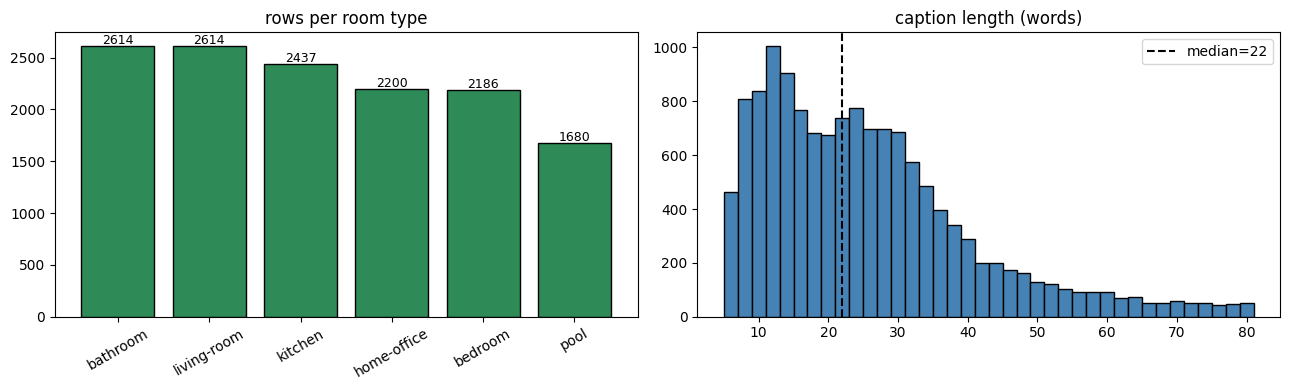

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['room_type'].value_counts()
axes[0].bar(counts.index, counts.values, color='seagreen', edgecolor='black')
axes[0].set_title('rows per room type')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

axes[1].hist(df['wc'], bins=range(5, 82, 2), color='steelblue', edgecolor='black')
axes[1].set_title('caption length (words)')
axes[1].axvline(df['wc'].median(), color='black', linestyle='--', label=f'median={df["wc"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# stratified train / val / test split (80 / 10 / 10)

In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['room_type'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['room_type'], random_state=42
)

print(f'train : {len(train_df):,}')
print(f'val   : {len(val_df):,}')
print(f'test  : {len(test_df):,}')

train : 10,984
val   : 1,373
test  : 1,374


# save   

In [14]:
df.to_csv('houzz_captioning.csv', index=False)
train_df.to_csv('train_caption.csv', index=False)
val_df.to_csv('val_caption.csv',     index=False)
test_df.to_csv('test_caption.csv',   index=False)

print('saved:')
for f in ['houzz_captioning.csv', 'train_caption.csv', 'val_caption.csv', 'test_caption.csv']:
    p = Path(f)
    print(f'  {f:25s}  {p.stat().st_size/1024:>8.1f} KB')

saved:
  houzz_captioning.csv         2848.0 KB
  train_caption.csv            2276.8 KB
  val_caption.csv               284.9 KB
  test_caption.csv              286.4 KB
